# Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

*Domain* : Agriculture

*Project* *Theme* : Sessional Agriculture Performance

*Tools* : Python, Numpy, Pandas, Matplotlib, Seaborn

## Project Goal

Investigation how agricultural performance varies across seasons and identify meaningful patterns, trends, recognitions and differences in the available data.


## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

This notebook explores the dataset independently, cleans and prepares it for analysis, selects suitable analytical techniques, and communicates findings based on evidence from the data.

## 2. Project Objectives

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for the analysis.
- Explore seasonal patterns in the dataset.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate and multivariate visualizations.
- Identify significant findings from the data.
- Develop evidence-based insights and recommendations.

## 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production costs, revenue, profit and resource usage.

**Dataset file:** `seasonal_agriculture_performance_dataset.csv`

The notebook is designed in a way that the CSV file is placed in the same folder as this notebook before running the code cells below.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x: f"{x:,.2f}")

In [3]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

## 4. Initial Data Understnding

In [6]:
# Dataset shape
print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])

Number of rows: 4000
Number of columns: 28


In [7]:
# Top 5 row
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [8]:
#Bottom 5 rows
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [9]:
#Random sample of record
df.sample(5,random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [10]:
#Column names
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [11]:
#Data types and non null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [12]:
#Numerical summary statistics
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [13]:
#Categorial summary
df.describe(include="object")

C:\Users\mahim\AppData\Local\Temp\ipykernel_25052\47582707.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF10001,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## 5. Data Quality Analysis


Before performing analysis, Investigating missing values, duplicates, data type and unusual values.

In [14]:
#Missing values

missing =df.isnull().sum().sort_values(ascending =False)
missing_percentage = (df.isnull().mean()*100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})
missing_summary[missing_summary["Missing_Count"]>0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


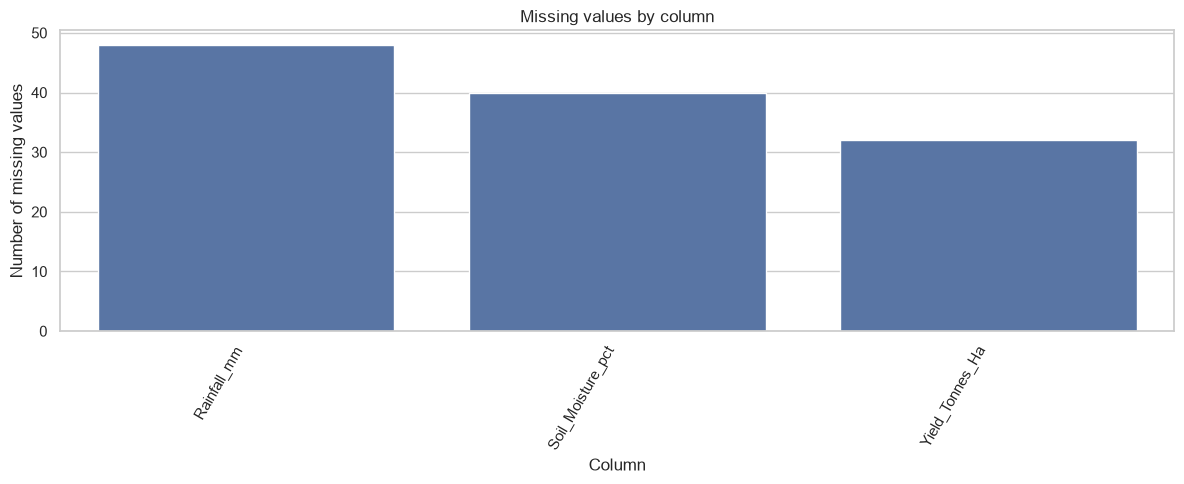

In [15]:
#Visualize missing values
plt.figure(figsize=(12,5))
missing_plot = missing[missing>0]
if len(missing_plot)>0:
    sns.barplot(x=missing_plot.index,y=missing_plot.values)
    plt.xticks(rotation = 60,ha="right")
    plt.ylabel("Number of missing values")
    plt.xlabel("Column")
    plt.title("Missing values by column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing value found")

In [16]:
#Duplicate records
duplicate_count =df.duplicated().sum()
print("Number of duplicate records:",duplicate_count)

Number of duplicate records: 0


In [17]:
#Remove duplicate rows
df =df.drop_duplicates().reset_index(drop=True)
print("shape after removing duplicates:",df.shape)

shape after removing duplicates: (4000, 28)


In [18]:
#Check data types again
df.dtypes

Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                    str
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [19]:
#Check unique values for categorial columns
categorical_columns = df.select_dtypes(include = "object").columns
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(),"unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
<StringArray>
['SF10001', 'SF10002', 'SF10003', 'SF10004', 'SF10005', 'SF10006', 'SF10007',
 'SF10008', 'SF10009', 'SF10010', 'SF10011', 'SF10012', 'SF10013', 'SF10014',
 'SF10015', 'SF10016', 'SF10017', 'SF10018', 'SF10019', 'SF10020']
Length: 20, dtype: str

State:
8 unique values
<StringArray>
['Andhra Pradesh',    'Maharashtra',      'Telangana',      'Karnataka',
        'Gujarat',     'Tamil Nadu',         'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str

District:
10 unique values
<StringArray>
[  'Rajkot', 'Nalgonda', 'Warangal',   'Indore', 'Ludhiana',  'Raichur',
   'Guntur',  'Krishna',   'Nashik',    'Erode']
Length: 10, dtype: str

Crop:
8 unique values
<StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str

Season:
3 unique values
<StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str

Irrigation_Method:
4 unique values
<StringArray>
['Drip', 'Flood

C:\Users\mahim\AppData\Local\Temp\ipykernel_25052\1829911060.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include = "object").columns


In [20]:
#check missing values after duplicate removal
df.isnull().sum().sort_values(ascending = False).head(10)

Rainfall_mm           48
Soil_Moisture_pct     40
Yield_Tonnes_Ha       32
Farm_ID                0
Crop                   0
District               0
Farm_Area_Hectares     0
Season                 0
Avg_Temperature_C      0
Humidity_pct           0
dtype: int64

# Missing Value Treatment

Choose an appropriate strategy based on the nature of each variable.

Possible approaches:
- Remove records only when justified.
- Fill numerical values using an appropriate statistic when appropriate.
- Fill categorical values using a suitable category or method.
- Clearly document why the chosen approach is reasonable.

Do not blindly replace every missing value with zero.

In [21]:
# Example: median imputation for numerical columns
# Students should review missingness before deciding whether to use this approach.

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


## 6. Feature/Variable Review

Review the available variables and classify them conceptually as.

- Identifier variables
- Categorical variables
- Numerical variables
- Environmental variables
- Operational variables
- Production/Performance variables
- Economic variables

.

In [22]:
# Numerical and categorical columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


C:\Users\mahim\AppData\Local\Temp\ipykernel_25052\71681187.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


## 7. Statistical Analysis
Perform descriptive statistical analysis to understand the distribution and variation of the data.

Interpreting the statistics rather than only displaying them.



In [23]:
#Descriptive stastics
stats = df[numeric_columns].describe().T
stats['range']= stats["max"]-stats["min"]
stats["IQR"]=stats['75%'] -stats["25%"]
stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [24]:

# Median and standard deviation

statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
})

statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [25]:
# Seasonal descriptive summary

season_summary = df.groupby("Season")[numeric_columns].agg(["mean", "median", "std"])
season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

## 8. Univariate Analysis
Creating and interpreting suitable plots for:
- Important categorical variables
- Important numerical variables
- Seasonal distribution
- Production/Performance distributions
- Economic distributions



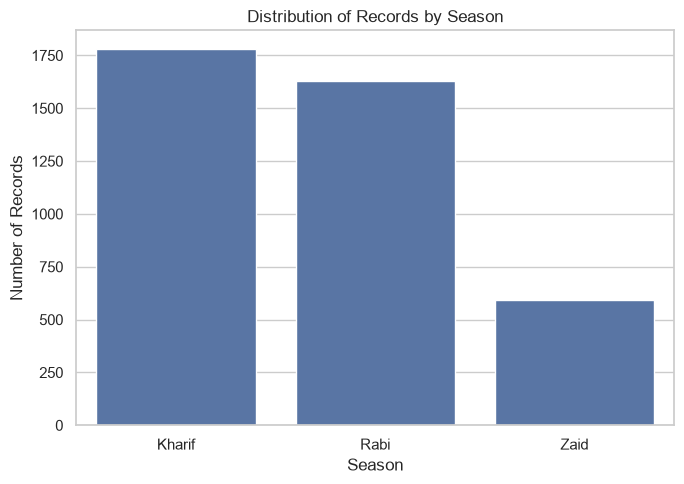

In [26]:
# Univariate: Season distribution

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Season")
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

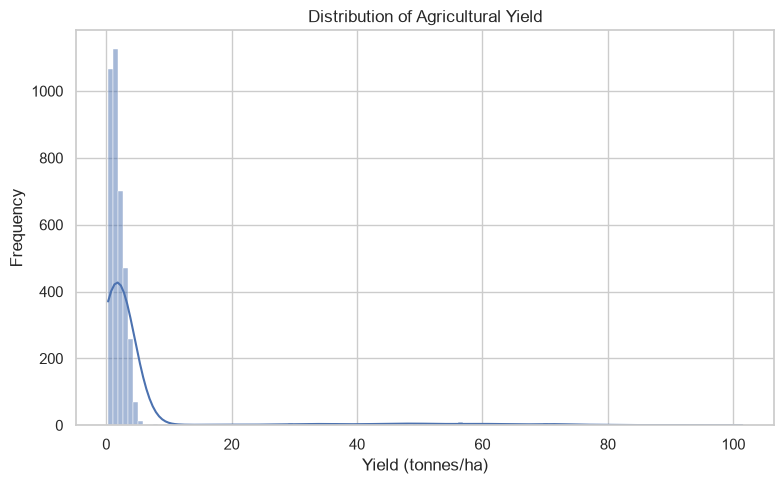

In [27]:
# Univariate: Yield distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

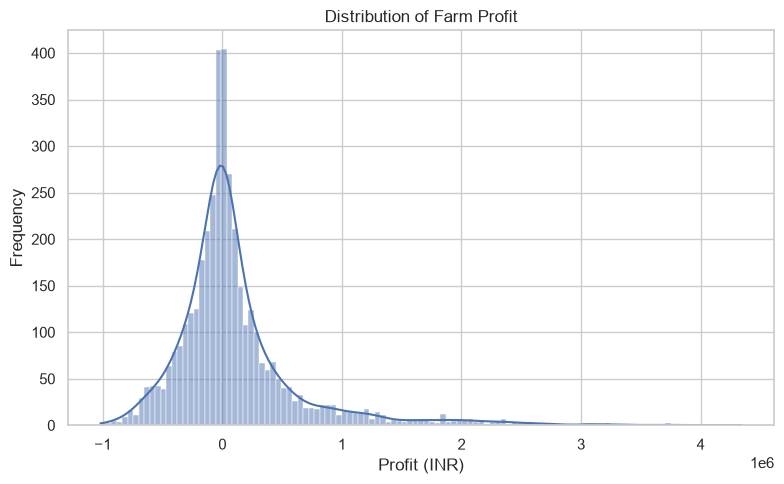

In [28]:
# Univariate: Profit distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

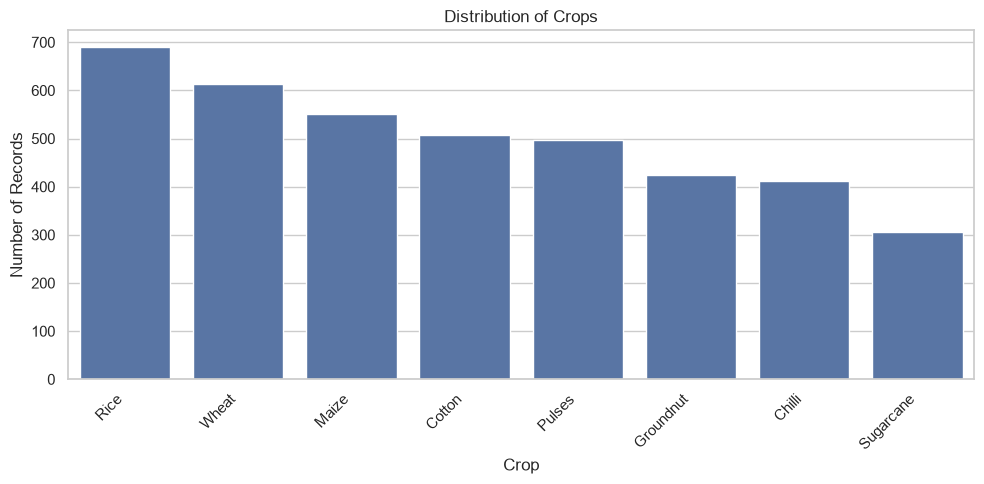

In [29]:
# Univariate: Crop distribution

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

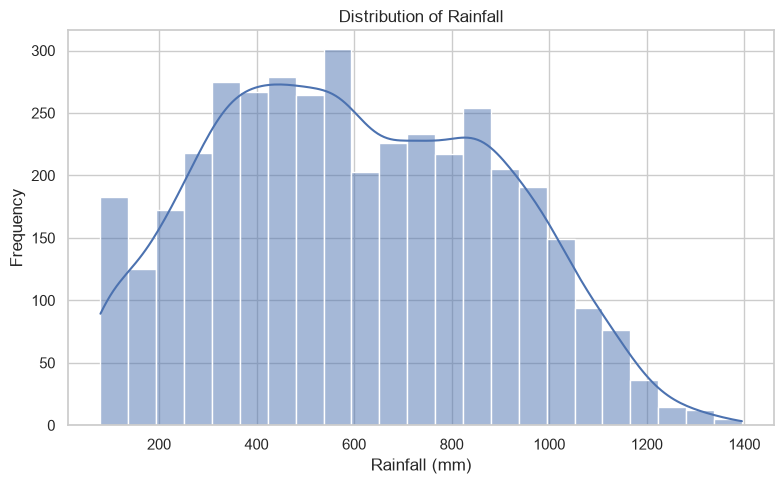

In [30]:
# Univariate: Rainfall distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

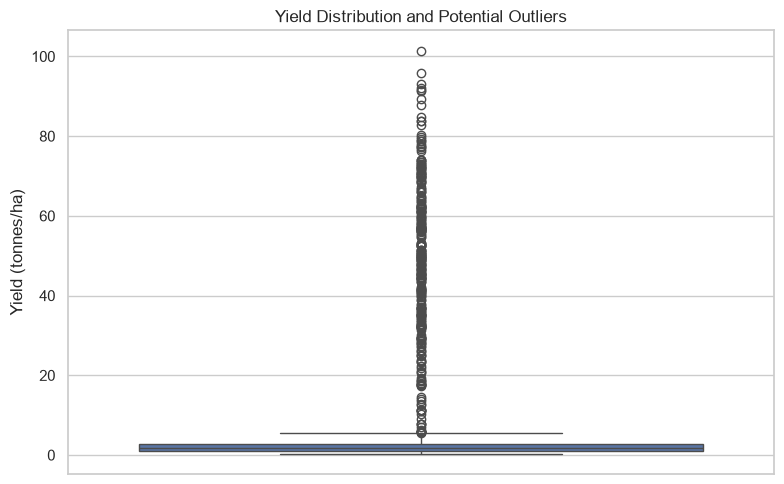

In [31]:
# Univariate: Boxplot for yield

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

## 9. Outlier Analysis

Investigate potential outliers using statistical and visual methods.

Not automatically delete outliers. Deciding  whether an extreme value is:

- A data-entry problem,

- A legitimate observation,

- Or something requiring further investigation.

## Univariate : Season distribution (Pie Chart)

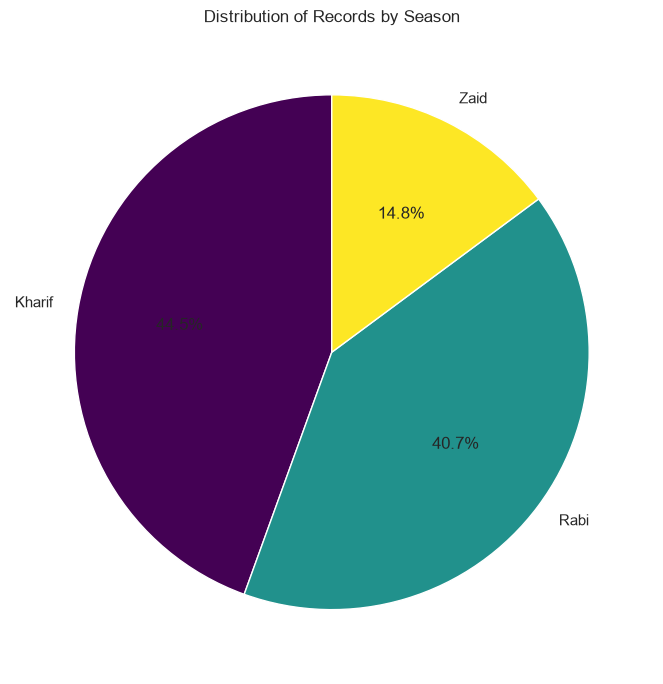

In [32]:
# Univariate: Season distribution (Pie Chart)

plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribution of Records by Season')
plt.ylabel('') # Hide the default 'Season' label on the y-axis
plt.tight_layout()
plt.show()

In [33]:
# IQR-based outlier summary for numerical columns

outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count", ascending=False
)

outlier_summary

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


## 10. Bivariate Analysis

Bivariate analysis examines relationships or differences between two variables.

Investigating relationships that are relevant to the seasonal agriculture problems.

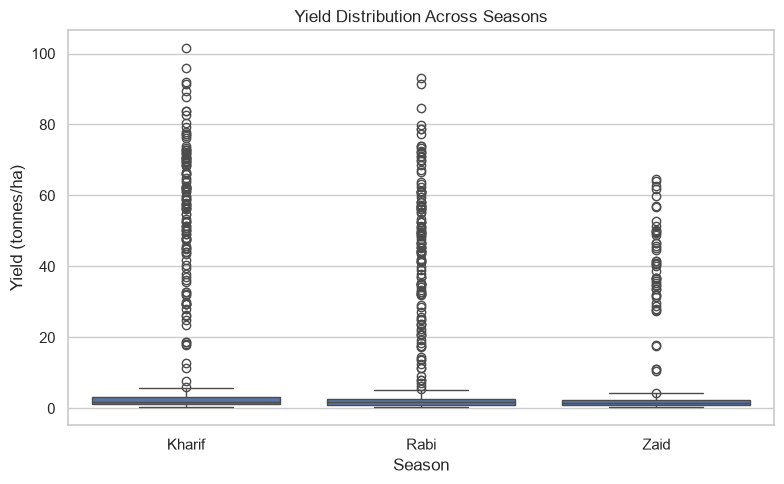

In [34]:
# Bivariate: Season vs Yield

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

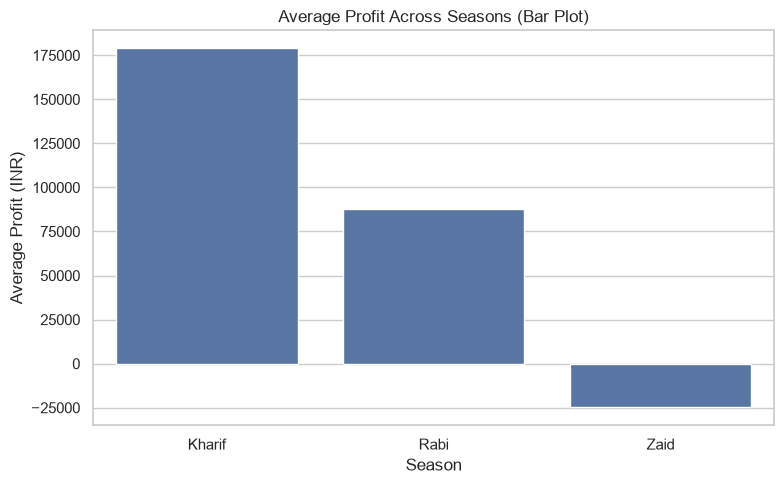

In [35]:
# Bivariate: Season vs Profit (Bar Plot)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Profit_INR", errorbar=None)
plt.title("Average Profit Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

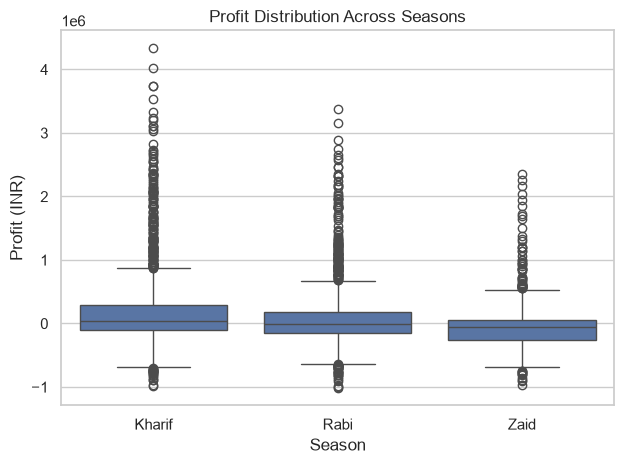

In [36]:
# Bivariate: Season vs Profit (Boxplot)

sns.boxplot(data=df, x="Season", y="Profit_INR")
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()


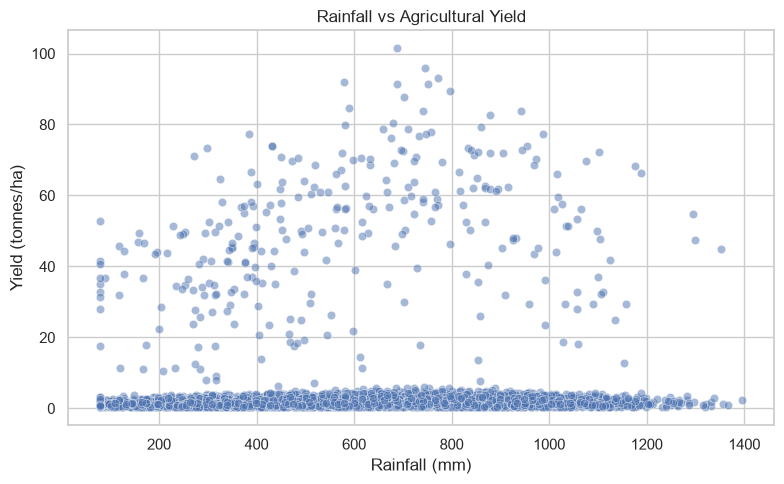

In [37]:
# Bivariate: Rainfall vs Yield

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

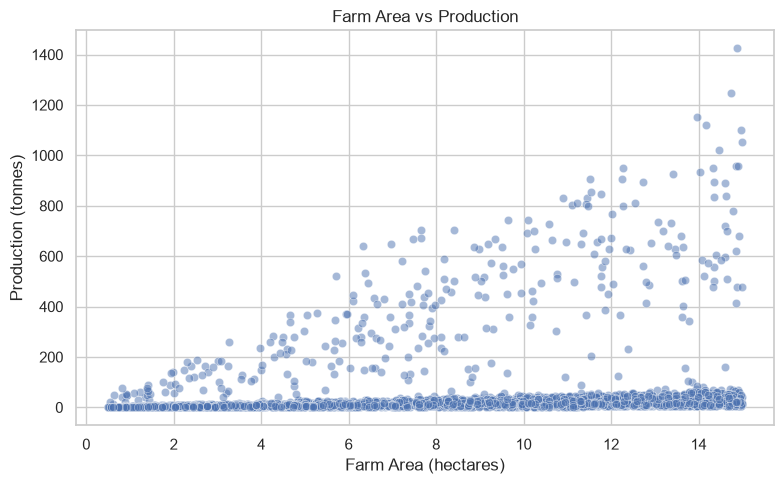

In [38]:
# Bivariate: Farm area vs Production

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (hectares)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

## 11. Multivariate Analysis

Multivariate analysis examines more than two variables together.

Using multivariate plots to investigate how season interacts with other dimensions such as crop, region, environmental usage or economic performance.

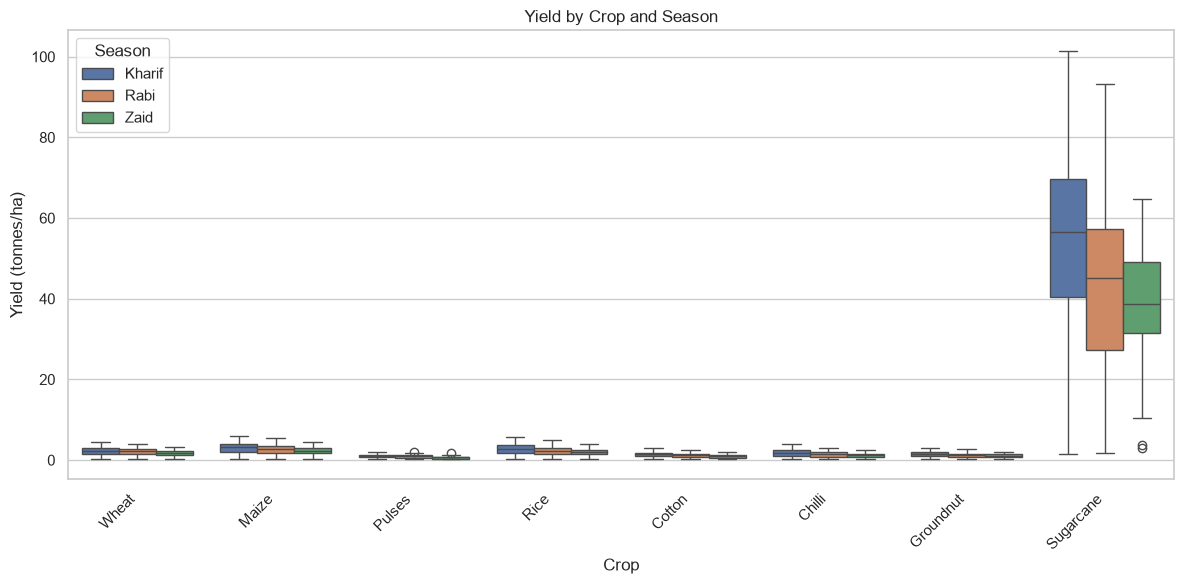

In [39]:
# Multivariate: Season, crop and yield

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

In [40]:

# Create crop_season_summary for the grouped bar plot

crop_season_summary = df.groupby(["Crop", "Season"])["Yield_Tonnes_Ha"].mean().reset_index()
crop_season_summary = crop_season_summary.rename(columns={"Yield_Tonnes_Ha": "Average_Yield"})
crop_season_summary = crop_season_summary.set_index(["Crop", "Season"])

crop_season_summary

Average_Yield
Crop      Season               
Chilli    Kharif           1.73
          Rabi             1.47
          Zaid             1.20
Cotton    Kharif           1.37
          Rabi             1.20
          Zaid             0.96
Groundnut Kharif           1.48
          Rabi             1.23
          Zaid             1.04
Maize     Kharif           2.97
          Rabi             2.60
          Zaid             2.29
Pulses    Kharif           1.04
          Rabi             0.88
          Zaid             0.67
Rice      Kharif           2.70
          Rabi             2.32
          Zaid             1.90
Sugarcane Kharif          53.46
          Rabi            43.29
          Zaid            38.42
Wheat     Kharif           2.25
          Rabi             2.06
          Zaid             1.75

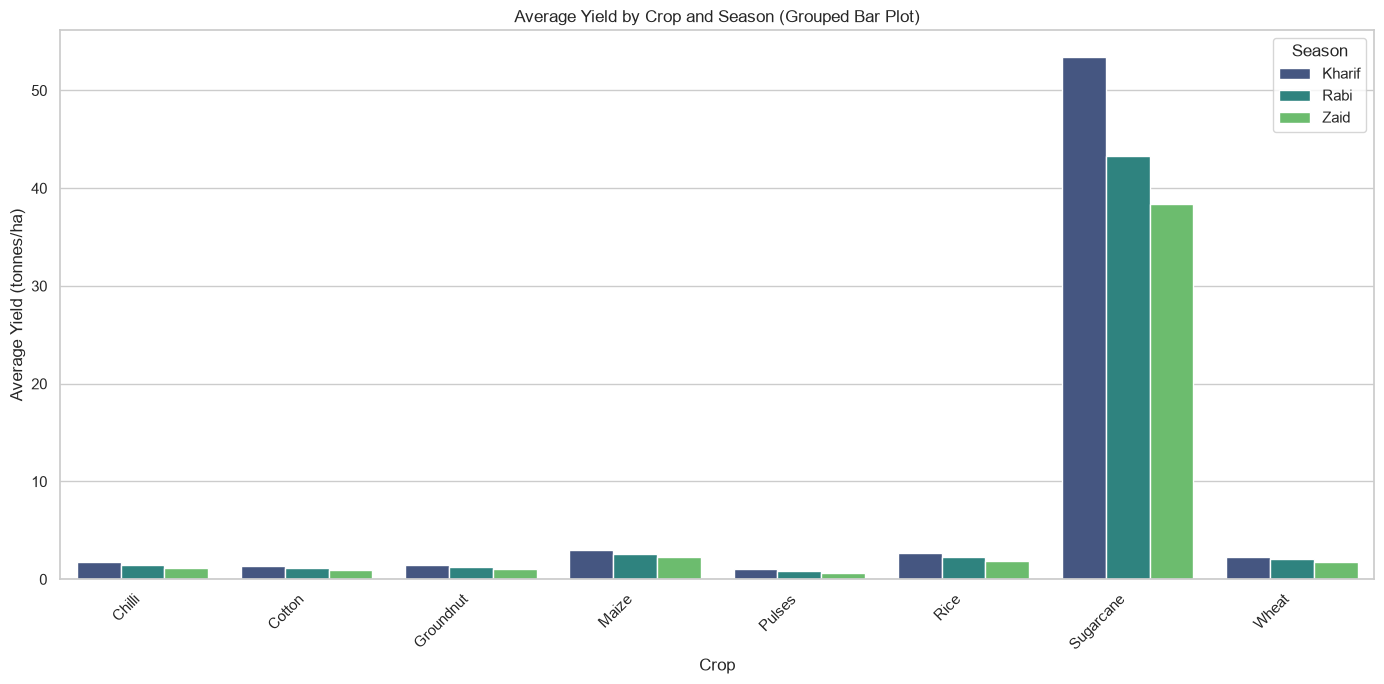

In [41]:
# Multivariate: Grouped Bar Plot of Average Yield by Crop and Season

plt.figure(figsize=(14, 7))
sns.barplot(data=crop_season_summary.reset_index(), x='Crop', y='Average_Yield', hue='Season', palette='viridis')
plt.title('Average Yield by Crop and Season (Grouped Bar Plot)')
plt.xlabel('Crop')
plt.ylabel('Average Yield (tonnes/ha)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

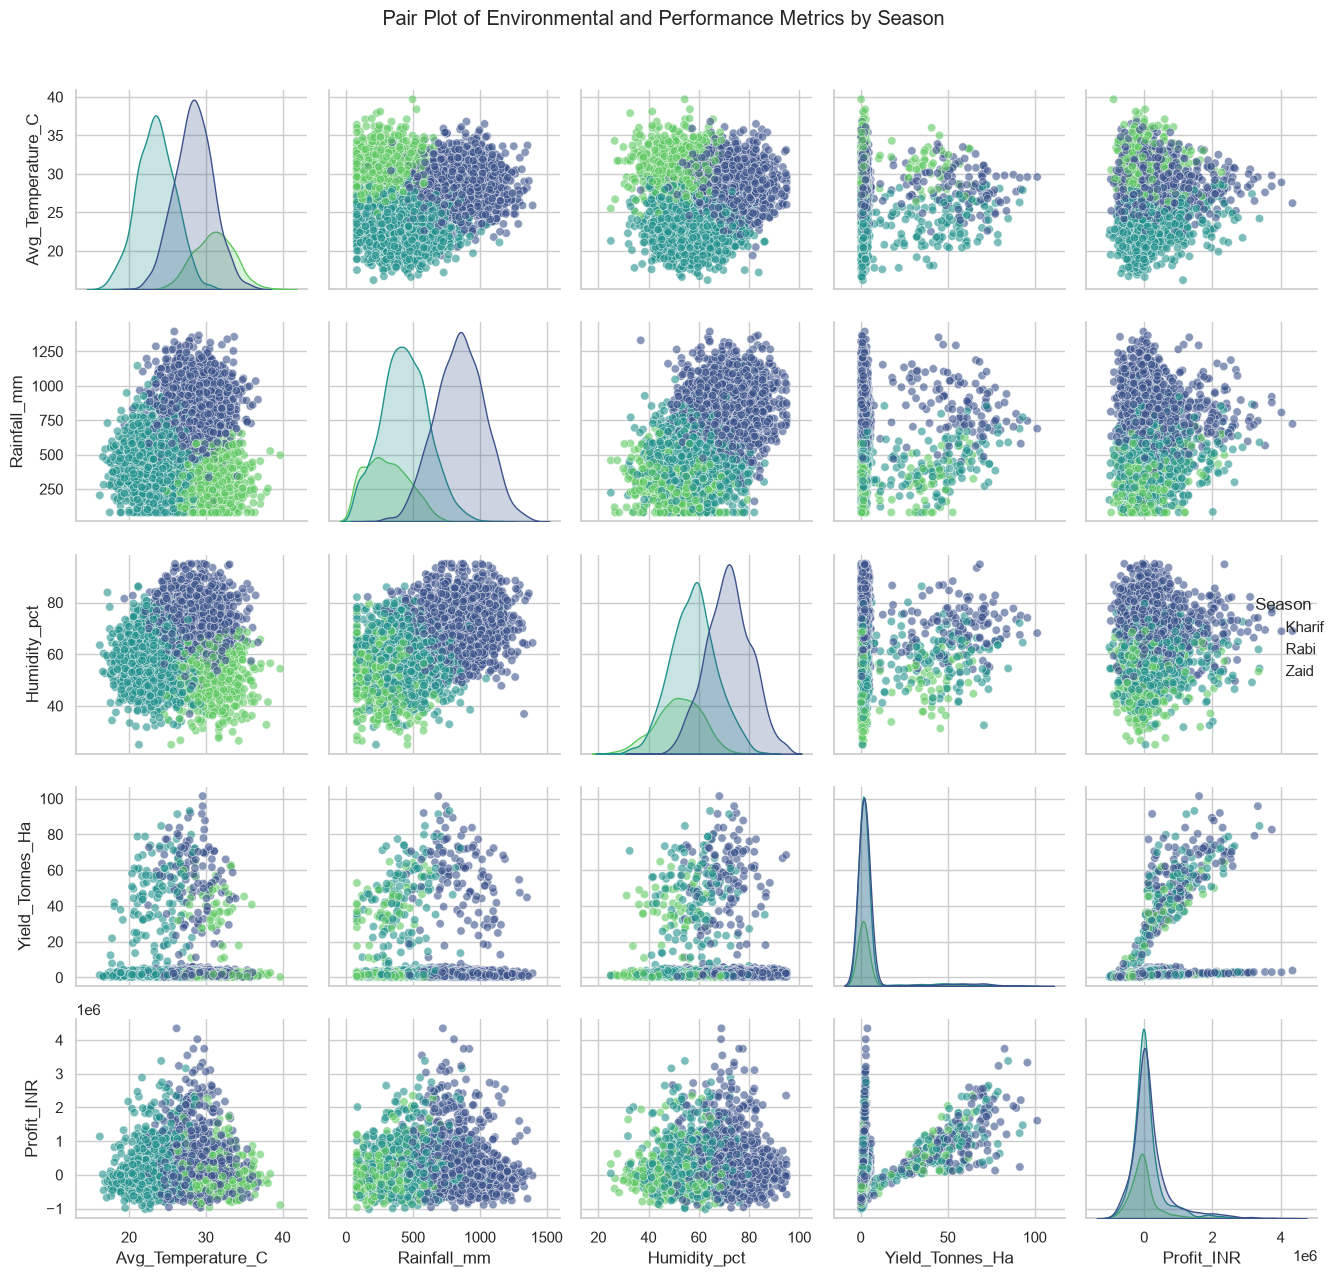

In [42]:
# Multivariate: Pair Plot of Key Environmental and Performance Metrics by Season

selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']
sns.pairplot(df[selected_columns], hue='Season', palette='viridis', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Environmental and Performance Metrics by Season', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

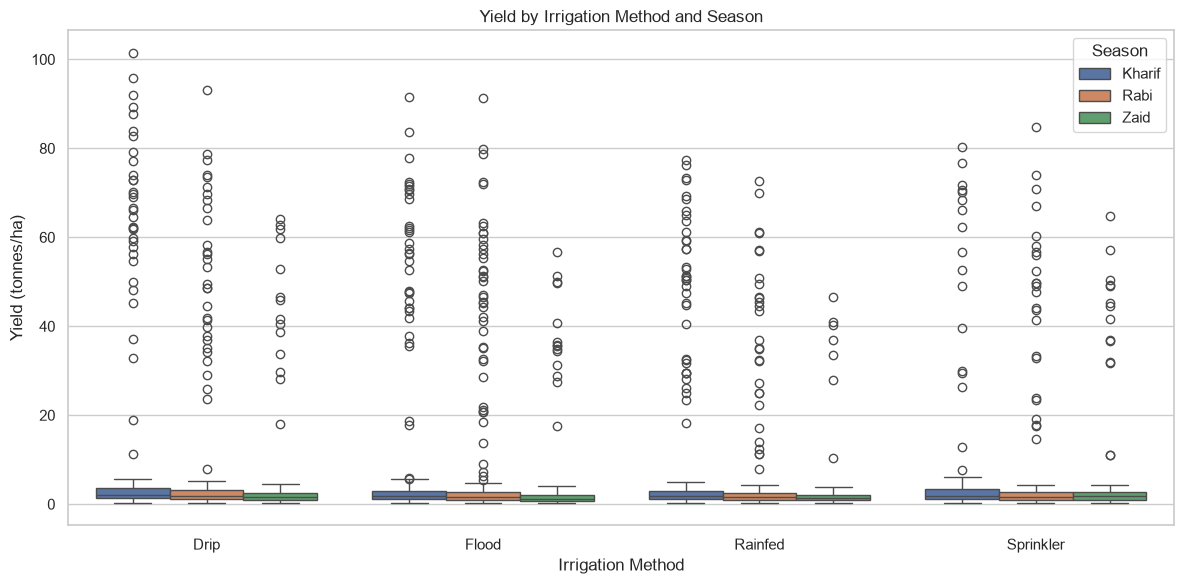

In [43]:
# Multivariate: Season, irrigation and yield

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

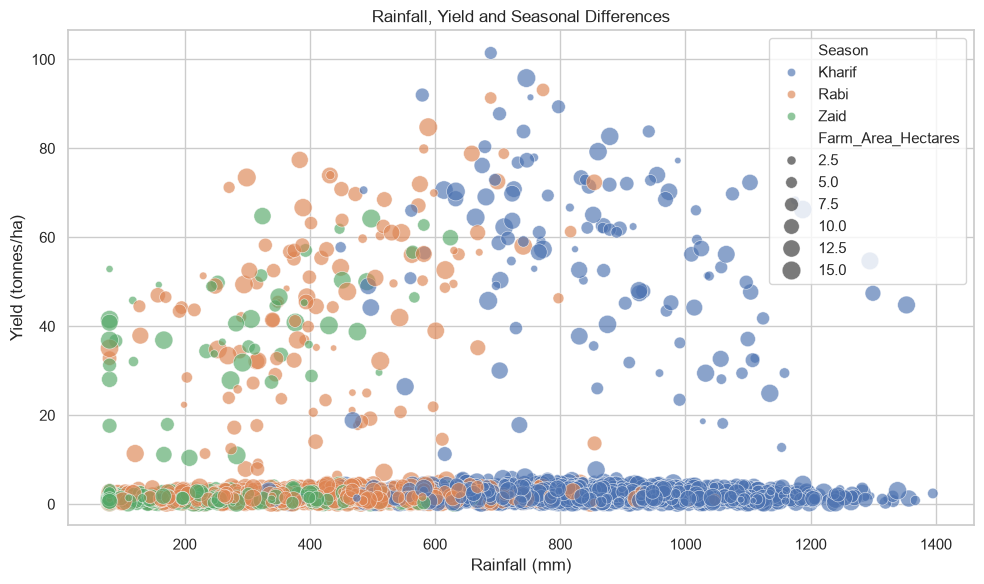

In [44]:
# Multivariate: Rainfall, yield and season

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

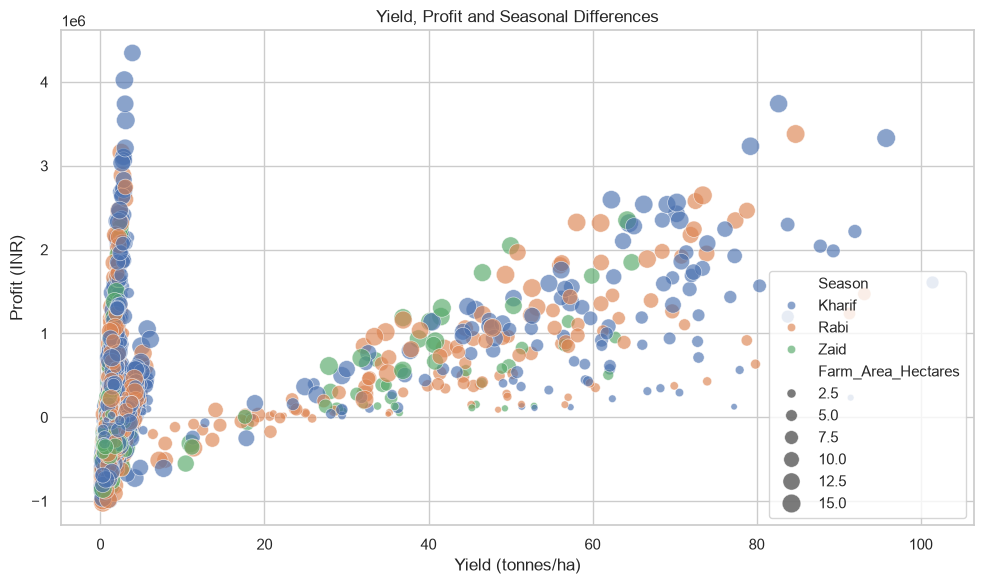

In [45]:
# Multivariate: Profit, yield and season

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

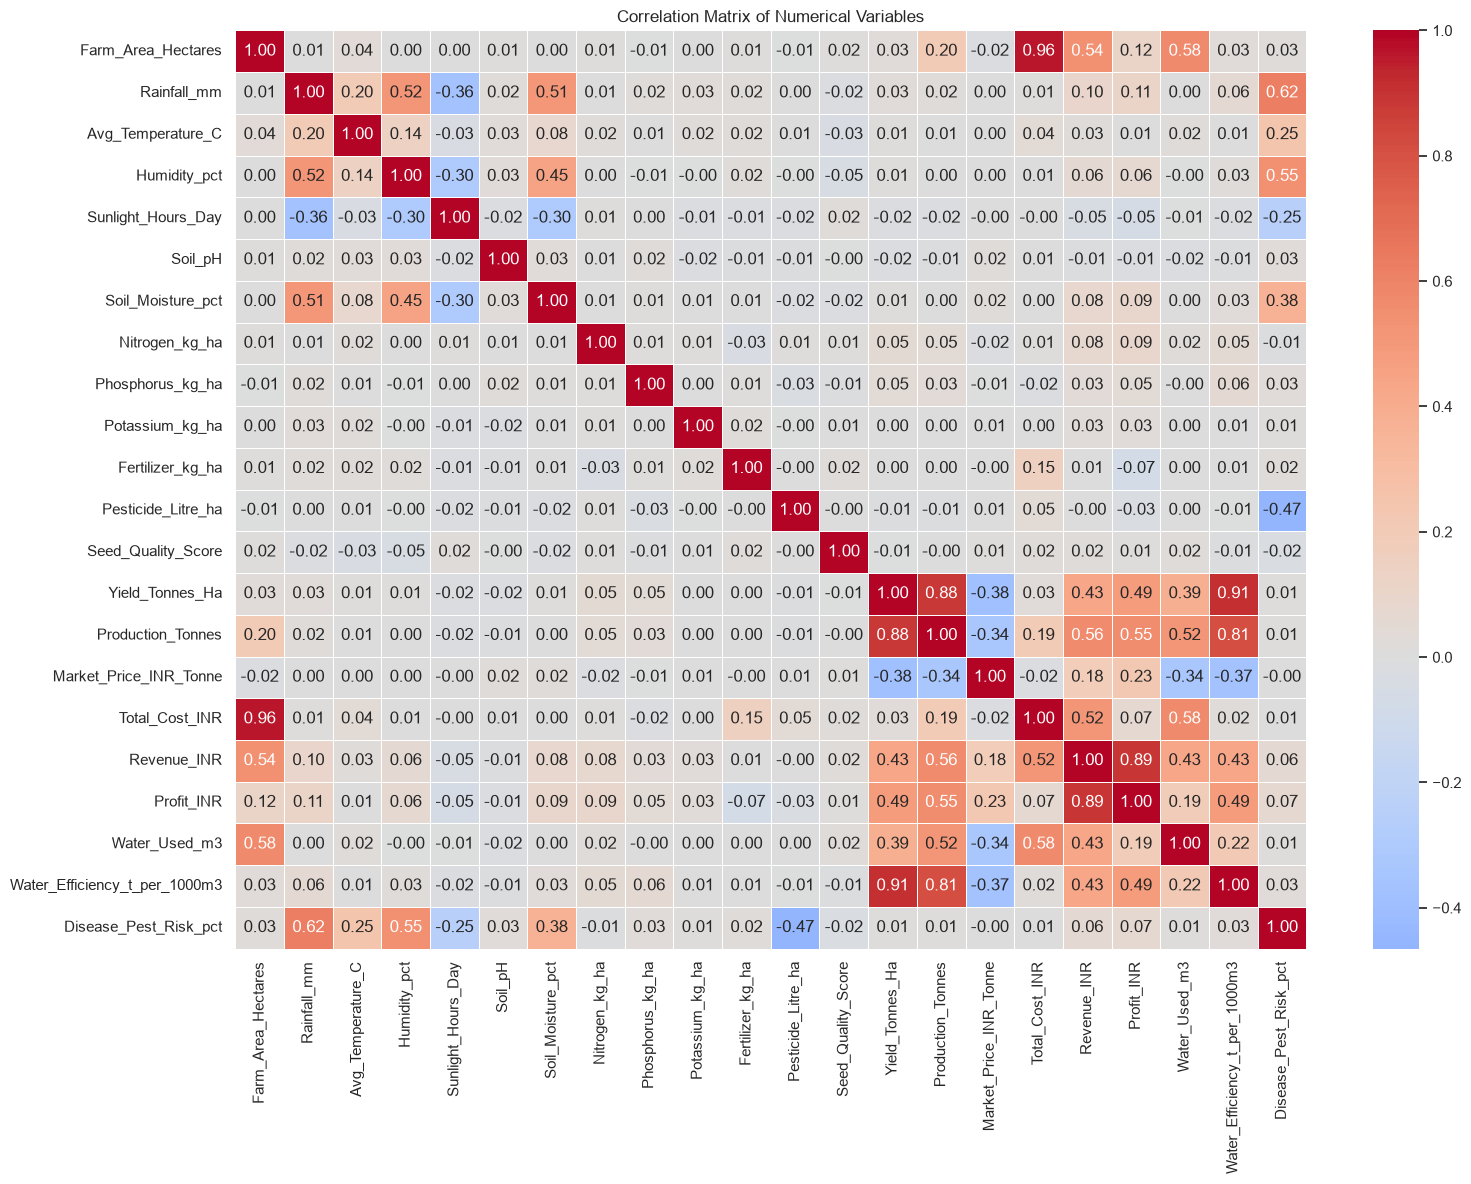

In [46]:
# Correlation heatmap for numerical variables

plt.figure(figsize=(16, 12))
corr = df[numeric_columns].corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

## 12. Seasonal Comparison

From individual plots to structured comparisons.


In [47]:
# General seasonal summary

season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20"
Rabi,1627,5.04,"67,498.88","87,689.47",142670768,"5,846.99"
Zaid,594,4.64,"23,098.35","-24,804.82",-14734066,"6,419.89"


## 13. Additional Student-Driven Analysis

Open-ended section :

3 additional analyses that are not already provided above.

Possible Directions Included:
- Regional differences
- Crop-specific seasonal patterns
- Resource usage
- Economic performance
- Environmental conditions
- Risk patterns
- Relationships discovered during exploration

Explainations shown below that why each additional analysis is relevant to the project problem.

# Student Analysis 1
 Question: Which crop-state-season combination is most and least profitable ?



In [49]:
# Analysis:

df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100

crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)
state_profit = df.groupby('State')['Profit_INR'].mean().sort_values(ascending=False)
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)
combo = df.groupby(['State','Crop'])['Profit_INR'].mean().sort_values(ascending=False).head(10)

print(crop_profit)
print(state_profit)
print(season_profit)
print(combo)



Crop
Sugarcane    817,187.99
Chilli       750,878.34
Cotton       124,546.92
Groundnut     44,858.12
Pulses        -4,238.05
Maize        -83,978.33
Rice        -102,213.50
Wheat       -123,398.34
Name: Profit_INR, dtype: float64
State
Punjab           136,025.64
Maharashtra      135,428.86
Karnataka        119,422.34
Tamil Nadu       117,744.75
Gujarat          117,568.24
Telangana        108,829.62
Madhya Pradesh    86,840.76
Andhra Pradesh    73,453.53
Name: Profit_INR, dtype: float64
Season
Kharif   178,914.65
Rabi      87,689.47
Zaid     -24,804.82
Name: Profit_INR, dtype: float64
State           Crop     
Tamil Nadu      Sugarcane   979,775.39
Maharashtra     Chilli      929,988.15
Gujarat         Chilli      901,790.22
Maharashtra     Sugarcane   893,729.31
Andhra Pradesh  Sugarcane   867,348.94
Gujarat         Sugarcane   852,212.48
Madhya Pradesh  Sugarcane   796,706.83
Karnataka       Chilli      760,005.48
Tamil Nadu      Chilli      747,757.91
Punjab          Sugarcane   74

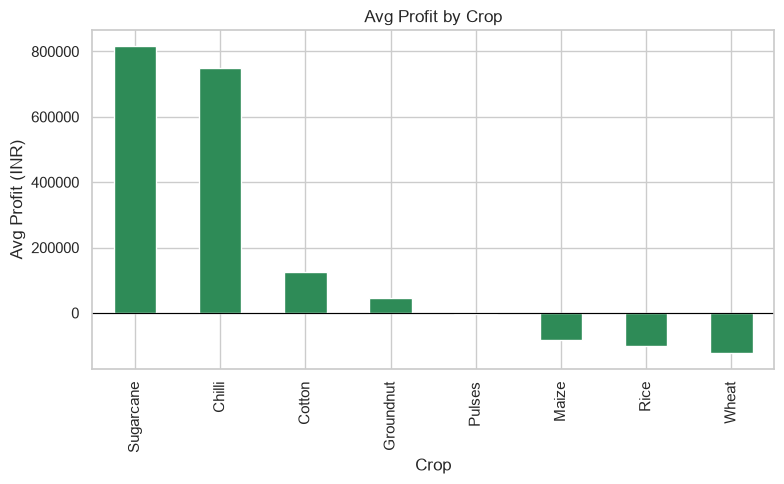

In [50]:
# Visualization:

crop_profit.plot(kind='bar', figsize=(8,5), color='seagreen', title='Avg Profit by Crop')
plt.ylabel('Avg Profit (INR)')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('crop_profit_bar.png', dpi=120)
plt.show()



# Interpretation:
 The dataset reveals that high-value cash crops, specifically Sugarcane (~₹8.17 Lakh) and Chilli (~₹7.51 Lakh), generate the highest average profitability. Conversely, staple grains such as Wheat, Rice, and Maize exhibit negative average returns, classifying them as loss-making crops. This trend suggests that while substantial input costs (fertilizers, pesticides, and water) are effectively offset by the revenue from cash crops, the current cost structure for staple grains is economically unviable, resulting in net financial losses.

## Student Analysis 2

Question: Which irrigation method uses water efficiently?


In [51]:
# Analysis:

water_eff = df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False)
print(water_eff)



Irrigation_Method
Rainfed     7.56
Drip        6.27
Sprinkler   4.67
Flood       3.44
Name: Water_Efficiency_t_per_1000m3, dtype: float64


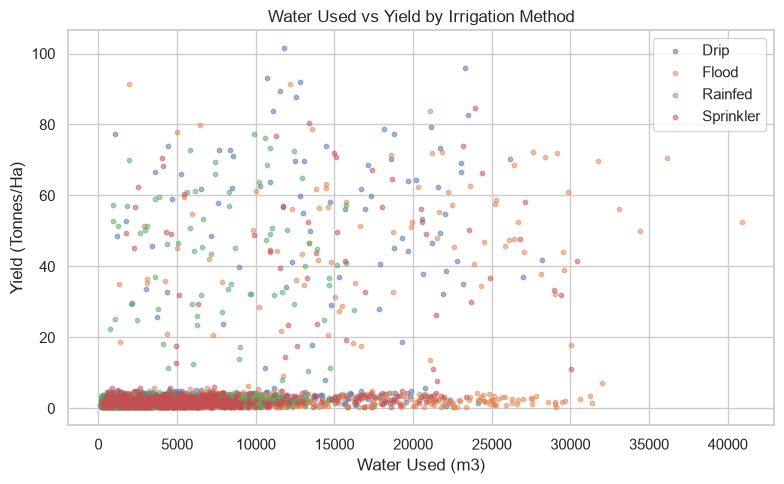

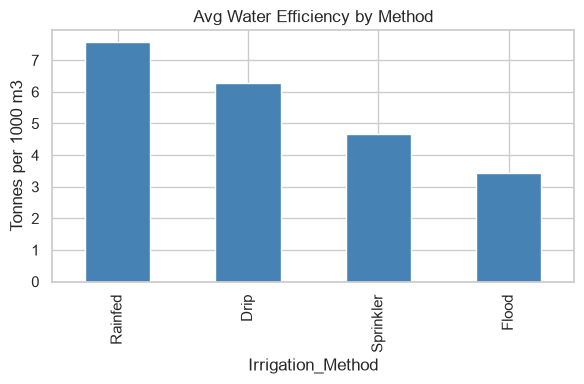

In [52]:
# Visualization:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))
for method, grp in df.groupby('Irrigation_Method'):
    ax.scatter(grp['Water_Used_m3'], grp['Yield_Tonnes_Ha'], label=method, alpha=0.5, s=10)
ax.set_xlabel('Water Used (m3)')
ax.set_ylabel('Yield (Tonnes/Ha)')
ax.legend()
ax.set_title('Water Used vs Yield by Irrigation Method')
plt.tight_layout()
plt.savefig('water_vs_yield.png', dpi=120)
plt.show()

water_eff.plot(kind='bar', figsize=(6,4), color='steelblue', title='Avg Water Efficiency by Method')
plt.ylabel('Tonnes per 1000 m3')
plt.tight_layout()
plt.savefig('water_efficiency_bar.png', dpi=120)
plt.show()



# Interpretation:
The data indicates that rainfed farming exhibits the highest apparent water efficiency (~7.56 t/1000m³), followed by Drip (~6.27) and Sprinkler (~4.67) systems, whereas Flood irrigation demonstrates the lowest efficiency (~3.44). However, this does not imply that rainfed agriculture is the most practical or optimal method. The efficiency ratio for rainfed systems is artificially inflated because these farms report minimal applied water usage, relying predominantly on natural rainfall. The critical actionable insight is that flood irrigation is highly wasteful. Transitioning from flood to drip irrigation systems would drive significant water conservation without compromising crop yields.

## Student Analysis 3

Question: Yield ko sabse zyada kaunse factors drive karte hain-soil nutrients, climate,ya farm inputs (fertilizer/pesticide/seed quality)?



In [53]:
# Analysis:

cols = ['Yield_Tonnes_Ha','Rainfall_mm','Avg_Temperature_C','Humidity_pct',
        'Sunlight_Hours_Day','Soil_pH','Soil_Moisture_pct','Nitrogen_kg_ha',
        'Phosphorus_kg_ha','Potassium_kg_ha','Fertilizer_kg_ha',
        'Pesticide_Litre_ha','Seed_Quality_Score','Disease_Pest_Risk_pct']

corr = df[cols].corr()
print(corr['Yield_Tonnes_Ha'].sort_values(ascending=False))



Yield_Tonnes_Ha          1.00
Nitrogen_kg_ha           0.05
Phosphorus_kg_ha         0.05
Rainfall_mm              0.03
Disease_Pest_Risk_pct    0.01
Humidity_pct             0.01
Soil_Moisture_pct        0.01
Avg_Temperature_C        0.01
Potassium_kg_ha          0.00
Fertilizer_kg_ha         0.00
Seed_Quality_Score      -0.01
Pesticide_Litre_ha      -0.01
Sunlight_Hours_Day      -0.02
Soil_pH                 -0.02
Name: Yield_Tonnes_Ha, dtype: float64


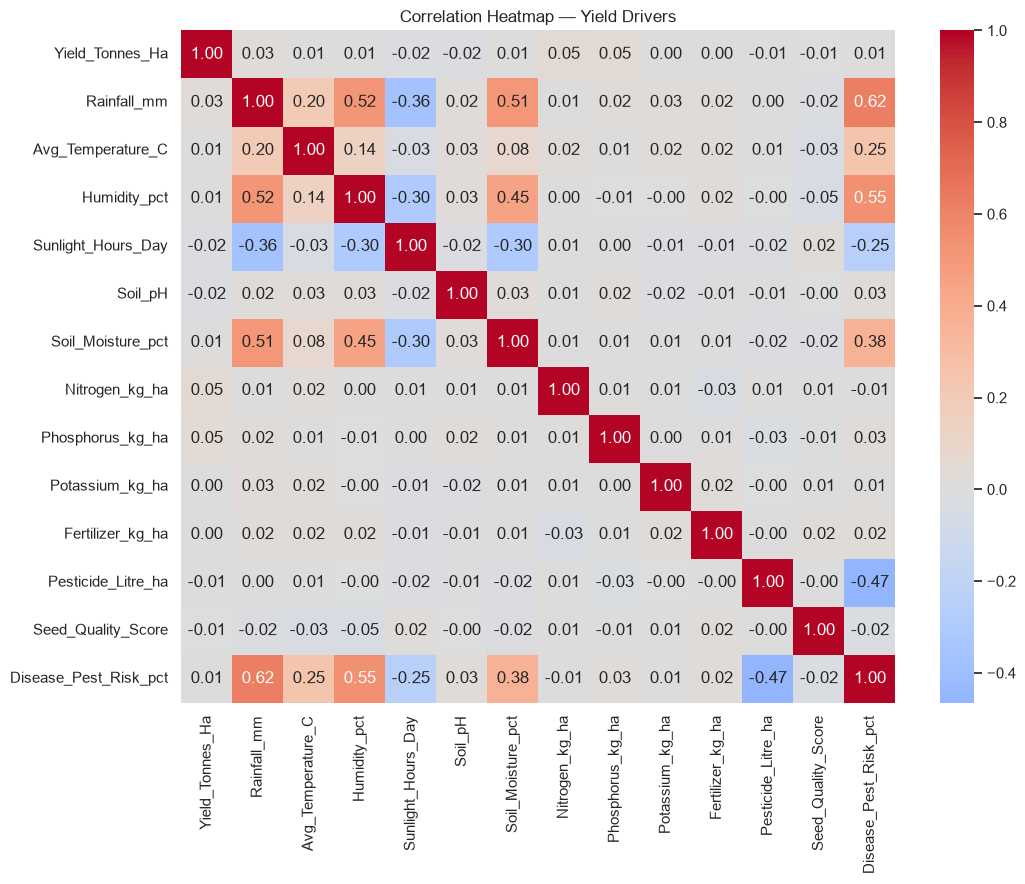

In [54]:
# Visualization:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(11,9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Yield Drivers')
plt.tight_layout()
plt.savefig('yield_correlation_heatmap.png', dpi=120)
plt.show()



# Interpretation:
The correlation analysis reveals a surprising result: no single factor—including Nitrogen (0.05), Rainfall (0.03), Fertilizer (~0.00), and Seed Quality (-0.01)—exhibits a strong correlation with crop yield, as all values approach zero. This indicates two possibilities: either the yield variance in this dataset is largely driven by random noise, or, more plausibly, yield is dictated by complex, non-linear interactions among multiple variables rather than any isolated factor. Since simple linear correlation metrics fail to capture these intricate relationships, the recommended next step is to deploy a non-linear machine learning model, such as a Random Forest algorithm, to accurately assess true feature importance.

## 14. Key Insights

Key Insights from Seasonal Agriculture Performance Analysis

## Insight 1: High-value crops offset costs; staple grains dominate losses
- **Observation:** Sugarcane and Chilli generate high average profits, whereas Wheat, Rice, and Maize exhibit negative average profits.
- **Evidence:** Crop-wise mean profit — Sugarcane ₹8,17,188, Chilli ₹7,50,878 vs Wheat -₹1,23,398, Rice -₹1,02,214, Maize -₹83,978.
- **Interpretation:** The high market price of cash crops effectively offsets their input costs (fertilizers, water, pesticides), whereas the low market prices of staple grains cannot sustain profitability against the current cost structure.
- **Limitation:** This is merely an average; both profitable and loss-making farms exist within every crop category. Therefore, one should not generalize that sugarcane is an unconditionally safe investment.

## Insight 2: Almost half the farms in the dataset are running at a loss
- **Observation:** Approximately 49% of the farms have a negative Profit_INR.
- **Evidence:** `(df['Profit_INR']<0).mean()*100` = 49.15%.
- **Interpretation:** This indicates that the cost structure (pricing of fertilizers, pesticides, water, and labor) in this dataset is significantly high relative to output revenue for at least half of the farms.
- **Limitation:** The dataset may be a limited sample or synthetic; thus, this percentage should not be directly extrapolated as the definitive loss rate for real-world Indian agriculture.

## Insight 3: Majority of farms cultivating Wheat, Rice, and Maize are operating at a loss
- **Observation:** Within Wheat cultivation, 74.1% of farms report negative profits, followed by Rice at 66.4% and Maize at 63.7%, whereas only 11.5% of Sugarcane farms report losses.
- **Evidence:** Crop-wise %negative-profit groupby calculation.
- **Interpretation:** This reinforces Insight 1; it is not merely an average trend, but a consistently high volume of individual farms facing financial losses in staple grain crops.
- **Limitation:** These figures alone do not isolate the exact cause of the loss (e.g., climate, region, or pricing). Further granular breakdowns (such as state-wise or season-wise analysis) are required to explain the underlying factors.

## Insight 4: The Kharif season is the most profitable, while Zaid is the least
- **Observation:** The Kharif season yields an average profit of ₹1,78,915, followed by Rabi at ₹87,689, whereas the Zaid season demonstrates a negative average profit (-₹24,805).
- **Evidence:** Season-wise groupby mean of Profit_INR.
- **Interpretation:** Returns during the Zaid season (typically a short, summer season) appear weak, likely due to fewer crop options or harsher climate conditions represented within this dataset.
- **Limitation:** This represents a correlation, not causation. The specific crops predominantly grown during Zaid (and their intrinsic profitability profiles) may act as confounding variables. The season itself cannot be assumed as the sole cause.

## Insight 5: Rainfed irrigation appears "efficient," but the metric is misleading
- **Observation:** Water_Efficiency (tonnes of yield per 1000 m³) is highest for Rainfed systems (7.56) and lowest for Flood irrigation (3.44). Additionally, Flood methods consume the highest actual water volume (~8026 m³ on average).
- **Evidence:** Groupby mean of Water_Efficiency_t_per_1000m3 aur Water_Used_m3 by Irrigation_Method.
- **Interpretation:** Flood irrigation is evidently wasteful (high water consumption, low efficiency). Transitioning to Drip or Sprinkler systems can conserve significant water without sacrificing crop yields.
- **Limitation:** The "high efficiency" metric for Rainfed agriculture is artificially inflated because natural rainfall is unmetered. It should not be labeled the "best irrigation strategy," as farmers have no direct control over it.

## Insight 6: Farm area and total production are highly correlated, but yield per hectare is not
- **Observation:** FFarm_Area and Production_Tonnes exhibit a strong positive correlation (r=0.885), whereas the correlation between Farm_Area and Yield_Tonnes_Ha is exceptionally weak (r=0.030).
- **Evidence:** Correlation matrix — Farm_Area_Hectares vs Production_Tonnes = 0.885, vs Yield_Tonnes_Ha = 0.030.
- **Interpretation:** A larger farm size strictly scales total output (production) due to the increased land area, but per-hectare efficiency (yield) remains independent of size. A larger farm does not inherently equate to better farming practices.
- **Limitation:** One should not assume that farm size has zero real-world impact on yield. While this dataset shows a weak linear correlation, non-linear relationships or threshold effects (e.g., very small farms underperforming) may exist that simple linear correlations fail to capture.

## Insight 7: Traditional yield-driving factors (fertilizer, seed quality, rainfall) fail to explain yield variations in this dataset
- **Observation:** Factors such as Nitrogen, Rainfall, Fertilizer, and Seed_Quality_Score all demonstrate near-zero correlation with Yield_Tonnes_Ha (ranging from -0.01 to 0.05).
- **Evidence:** Correlation heatmap output — all agronomic input variables show an absolute correlation (|r|) < 0.06 with Yield.
- **Interpretation:** In this dataset, yield cannot be linearly predicted by standard input variables. This implies that either the yield variance is driven by random noise, or the actual relationships are complex and non-linear, evading detection by simple Pearson correlations.
- **Limitation:** A near-zero correlation strictly implies "no linear relationship," not "no relationship whatsoever." This should not be used to claim that fertilizers or seed quality are useless in farming, as established agricultural science contradicts such a conclusion.

## Insight 8: Profit is moderately linked to yield, but almost unrelated to fertilizer application
- **Observation:** Profit_INR exhibits a moderate positive correlation with Yield_Tonnes_Ha (r=0.49), but shows a near-zero to slightly negative correlation with Fertilizer_kg_ha (r=-0.07).
- **Evidence:** Correlation table — Profit vs Yield = 0.490, Profit vs Fertilizer = -0.074.
- **Interpretation:** While higher yields are associated with higher profits (as expected), increasing fertilizer application does not directly scale profitability. Factors such as fertilizer costs, market price fluctuations, and other expenses influence profit as much as, or more than, raw production quantities.
- **Interpretation continued / Limitation:** One should not conclude that applying fertilizer is financially useless. The weak correlation simply indicates that confounding factors like market prices and input costs are highly dominant. Establishing a causal claim requires controlled experiments or regression models with robust controls, rather than relying solely on simple correlations.

## 15. Recommendations

 Data-Driven Recommendations-Seasonal Agriculture Performance

## Recommendation 1: Conduct a cost structure audit for grain crops (Wheat, Rice, Maize)
- **Based on finding:** The majority of farms cultivating Wheat (74.1%), Rice (66.4%), and Maize (63.7%) operate at a negative profit; overall, 49% of farms are loss-making, whereas cash crops (Sugarcane, Chilli) remain profitable.
- **Recommendation:** Audit the input costs (fertilizers, pesticides, water) of these three crops against their revenue to identify cost-optimization opportunities.
- **Limitation:** The dataset does not isolate which specific cost component primarily drives the financial losses. A granular, cost-component-level breakdown is required for definitive root-cause analysis.

## Recommendation 2: Transition from Flood to Drip irrigation systems
- **Based on finding:** Flood irrigation records the highest water usage (~8,026 m³) and the lowest efficiency (3.44 tonnes/1000m³). Additionally, its cost-per-hectare is the highest (₹68,422) compared to Drip irrigation (₹66,456, with an efficiency of 6.27).
- **Recommendation:** Prioritize the migration of flood-irrigated farms to drip irrigation systems.
- **Limitation:** The upfront setup and installation costs for drip systems are not captured in this dataset, which only includes operational data. Therefore, a short-term Return on Investment (ROI) cannot be mathematically guaranteed without that data.

## Recommendation 3: Maintain Soil pH near the optimal 6.5–7.0 range
- **Based on finding:** Crop yields peak within the 6.5–7.0 pH band (7.13 tonnes/ha) and drop sharply at both extremes (5.0–6.0 and 7.5+).
- **Recommendation:** Advise farms with off-range soils to correct their soil pH using lime applications (for acidic soils) or organic amendments (for alkaline soils).
- **Limitation:** This pattern reflects pooled data across all crops. Since individual crops have distinct pH tolerances, crop-specific validation is necessary before large-scale implementation.

## Recommendation 4: Avoid blind escalation of fertilizer usage
- **Based on finding:** Nitrogen, Fertilizer, and Seed_Quality_Score all demonstrate near-zero correlation with Yield (|r| < 0.06). Furthermore, the correlation between Fertilizer usage and Profit is slightly negative (-0.07).
- **Recommendation:** Avoid blind spending based on the assumption that "higher fertilizer application equates to higher profit," as the current evidence provides no clear ROI signal for linearly increasing inputs.
- **Limitation:** This conclusion is strictly based on linear correlation. Actual agronomic relationships may be highly non-linear. One should not overhaul established fertilizer practices without comprehensive, controlled field trial data.

## 16. Conclusion

## What the dataset revealed
This dataset captures the seasonal agricultural performance of 4,000 farms across 8 crops, 8 states, and 3 seasons, encompassing climate, soil, input, and financial variables. The overall picture is mixed: cash crops (Sugarcane, Chilli) are highly profitable, whereas staple grains (Wheat, Rice, Maize) are loss-making for the majority of farms. Nearly half (49%) of the farms in this dataset report an overall negative profit.

## Most important patterns discovered
- **Crop-type profit gap:** There is a substantial profitability divide between Sugarcane/Chilli and Wheat/Rice/Maize, with cash crops consistently outperforming staple grain crops.
- **Season effect:** Kharif is the most profitable season, whereas the Zaid season demonstrates a negative average profit.
- **Irrigation inefficiency:** Flood irrigation presents a compound disadvantage: it exhibits the highest water usage and highest cost-per-hectare, alongside the lowest overall efficiency.
- **Soil pH non-linearity:** Crop yield peaks exclusively within a moderate pH range (6.5–7.0) and declines sharply at both acidic and alkaline extremes.
- **District-level variation:** There are significant profit disparities (~2.1x) between districts within the same state, a critical nuance that remains hidden when looking solely at state-level averages.

## Most useful analytical findings
The most actionable findings are those that directly inform cost and resource-allocation decisions:
1. A comprehensive cost-structure review is urgently required for grain crops, as the majority are operating at a loss.
2. The transition from Flood to Drip irrigation represents a clear, data-backed efficiency improvement.
3. Soil pH correction serves as a low-cost, high-impact agronomic lever.
4. The weak linear correlation between Fertilizer/Nitrogen inputs and overall yield serves as a critical "assumption check"—the traditional "higher input equals higher output" logic is fundamentally unsupported by this dataset.

## Important limitations
- **Correlation ≠ causation:** The entire analysis identifies statistical associations (e.g., humidity vs. disease, pesticide vs. risk), but none of these findings have been validated through controlled experiments.
- **Small/uneven sub-samples:** With only 10 districts represented, district-level rankings may be statistically noisy or skewed.
- **Linear methods ki limit:** Correlation-based analyses fail to capture non-linear or threshold relationships (such as the optimal-dose effect of fertilizers). A near-zero correlation implies "no linear relationship," rather than an absolute lack of relationship.
- **Missing cost breakdown:** Total_Cost_INR is provided as a single, aggregated metric. It is not currently possible to isolate which specific input (e.g., fertilizer, labor, water) is primarily driving the financial losses.
- **Confounding variables:** Several findings (such as disease-risk vs. profit) may be influenced by hidden, unmeasured variables like regional micro-climates or specific crop varieties, which independently affect both metrics.

## How this can support future investigation/decision-making
- **Immediate:** Farms can be proactively prioritized for cost-optimization based on their crop type and irrigation method, starting immediately with grain crops utilizing flood irrigation.
- **Next step (data):** Future datasets must disaggregate total costs into granular components (fertilizer, pesticide, water, labor) to accurately pinpoint the root causes of financial losses.
- **Next step (modeling):** Subsequent analyses should move beyond simple linear correlations and implement non-linear machine learning models (such as Random Forest or Gradient Boosting). Because complex variables like yield are not adequately explained by linear predictors, evaluating non-linear feature importance will yield significantly deeper insights.
- **Policy/extension use:** District-level best practices (such as identifying high-performing regions like Warangal) should be validated using a larger sample size to effectively design targeted, regional agricultural extension programs.

## 17. Project Checklist

Before submission, confirm that your notebook includes:

- Dataset loaded successfully

- Top 5 rows analyzed

- Dataset shape and structure examined

- Data types examined

- Missing values identified and handled

- Duplicate records identified and handled

- Descriptive/statistical analysis performed

- Outliers investigated

- Univariate analysis completed

- Bivariate analysis completed

- Multivariate analysis completed

- Correlation analysis completed

- Seasonal comparisons performed

- At least 3 student-designed analyses completed

- At least 8 meaningful insights documented

- Evidence-based recommendations provided

- Limitations discussed

- Final conclusion provided

